In [63]:
# Install gmplot to create a satelite view of the driven path based on GPS coordinates
!pip install gmplot

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
import gmplot as gmplot
import pandas as pd
import os

In [65]:
def Draw_Plots(time, Position, Speed, Acceleration, filename, Time_Section, transparency):

    # Set subplots in a large figure
    fig, (subfig1, subfig2, subfig3) = plt.subplots(3, figsize = (9,8))

    # Plot Position
    subfig1.plot(time, Position)
    subfig1.set_ylabel('Position (m)')
    subfig1.grid(True)
    subfig1.minorticks_on()
    subfig1.grid(which='minor', linestyle = ':')
    subfig1.set_xlabel('Time (s)')

    # Plot Speed
    subfig2.plot(time, Speed)
    subfig2.set_ylabel('Speed (km/h)')
    subfig2.grid(True)
    subfig2.minorticks_on()
    subfig2.grid(which='minor', linestyle = ':')
    subfig2.set_xlabel('Time (s)')
    subfig2.set_ylim([0,120])

    # Plot Acceleration
    subfig3.plot(time, Acceleration)
    subfig3.set_ylabel('Acc (m/s^2)')
    subfig3.set_xlabel('Time (s)')
    subfig3.set_ylim([-4,3])
    subfig3.grid(True)
    subfig3.minorticks_on()
    subfig3.grid(which='minor', linestyle = ':')


    fig.suptitle('Vehicle States')
    plt.tight_layout()

    # Save figures
    print(filename)
    plt.savefig(filename + ' States.png')
    plt.show()

In [66]:
def Accel_and_Pos(Speed, Latitude, Longitude, dt = 0.04):

    # Calculate acceleration in m/s^2
    Acceleration = np.gradient(np.multiply(Speed,(5/18)),dt)

    # Get Moving Average of Acceleration to filter the noise
    windowsize = 10
    for i in range(len(Acceleration)):
        Acceleration[i] = Acceleration[i:i+windowsize].mean()

    # Compute Position(m)
    Position = haversine(Latitude, Longitude)

    return Acceleration, Position

In [67]:
# Calculate Position(m) based on GPS coordinates, check haversine formula
def haversine(lat, lon):

    Position = np.zeros(len(lat))
    Position[0] = 0

    for i in range(len(lat)-1):
        lat1 = lat[i]
        lat2 = lat[i+1]
        lon1 = lon[i]
        lon2 = lon[i+1]

        # distance between latitudes
        # and longitudes
        dLat = (lat2 - lat1) * np.pi / 180.0
        dLon = (lon2 - lon1) * np.pi / 180.0

        # convert to radians
        lat1 = (lat1) * np.pi / 180.0
        lat2 = (lat2) * np.pi / 180.0

        # apply formulae
        a = (pow(np.sin(dLat / 2), 2) +
            pow(np.sin(dLon / 2), 2) *
                np.cos(lat1) * np.cos(lat2))

        R = 6378137; # Earth radius in METERS
        c = 2 * np.sin(np.sqrt(a))

        Position[i+1] = Position[i] + R * c

    return Position

In [68]:
def Gmaps(Latitude, Longitude, filename):

  # Create Google maps object based on initial coordinates and zoom
  gmap3 = gmplot.GoogleMapPlotter(31.8188, -106.5156, 13)

  # Plot method Draw a line in between given coordinates
  gmap3.plot(Latitude, Longitude, 'cornflowerblue', edge_width = 2.5)

  gmap3.draw( filename + ".html" )

  return

In [69]:
def Match_Radar_Time(file,file_foll):

  Racebox_file = pd.read_csv(file)
  Radar_file = pd.read_csv(file_foll)

  Racebox_Time = Racebox_file['Time'].tolist()
  Radar_Time = Radar_file['timestamp'].tolist()
  Frame_index = Radar_file['frame_index_zeroed'].tolist()
  Frame_index = np.array(Frame_index)

  #Ensure index starts from 0
  if (Frame_index[0] != 0):
    Frame_index = Frame_index - Frame_index[0]

  # Make data pd.datetime64
  Racebox_Time = pd.to_datetime(Racebox_Time)
  Radar_Time = pd.to_datetime(Radar_Time)

  # Align Time to UTC
  # Racebox Time is automatically in UTC
  Racebox_Time = Racebox_Time.tz_localize('UTC')
  Radar_Time = Radar_Time.tz_localize('America/Ciudad_Juarez')
  Radar_Time = Radar_Time.tz_convert('UTC')

  # Add Average Time offset of +0.8 sec PLUS +20 sec delay from dashcam
  Radar_Time = Radar_Time + pd.Timedelta(seconds=20.8)

  # Create a mask to slice data
  start = pd.Timestamp(Radar_Time[0])
  end = pd.Timestamp(min(Radar_Time[Radar_Time.argmax()], Racebox_Time[Racebox_Time.argmax()]))

  mask = (Racebox_Time >= start) & (Racebox_Time <= end)
  Racebox_Time = Racebox_Time[mask]

  mask2 = (Radar_Time >= start) & (Radar_Time <= end)
  Radar_Time = Radar_Time[mask2]
  Frame_index = Frame_index[mask2]

  elapsed_time = (Racebox_Time - Racebox_Time[0]).total_seconds()

  return mask, Frame_index, elapsed_time


#Mesa - Follower 1
Sync Racebox and Radar

/content/Mesa-Sync_GV_Follower1_data 12-43


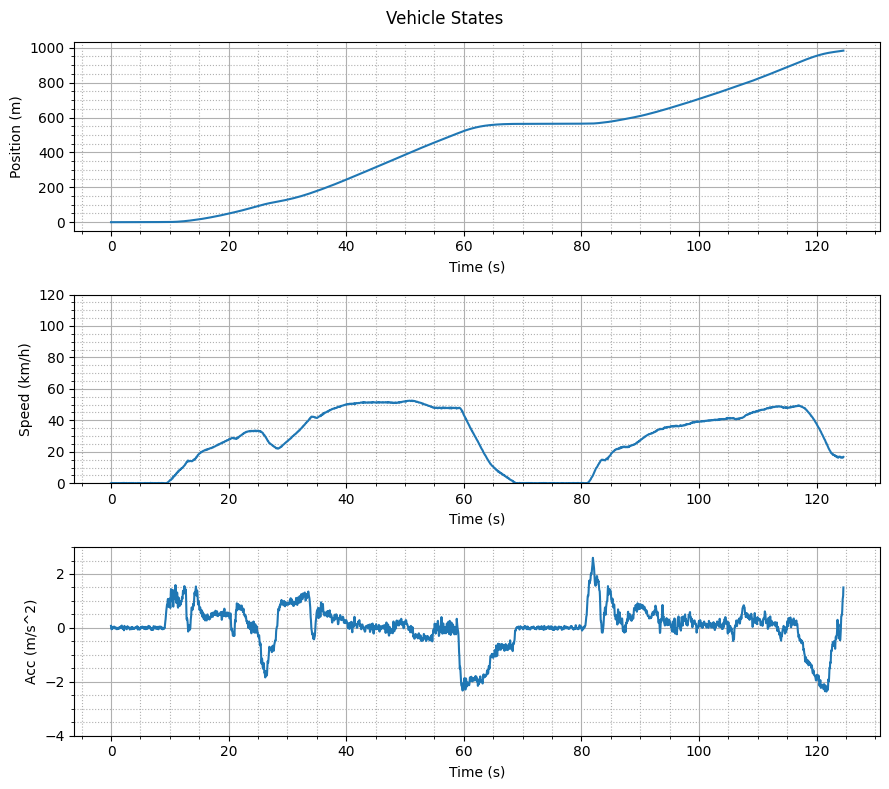

In [70]:
directory = '/content/'
file = 'RaceBox Track Sessionon 22-03-2026 12-43.csv' # Racebox data file
file_foll = 'Mesa_8_KF_Final_Rep_Removed.csv'         # Processed Radar data file

filename = directory + file

mask, index, elapsed_time = Match_Radar_Time(file,file_foll)

Racebox_file = pd.read_csv(file)

#------------------------------------------------------------
# Apply mask to slice Racebox data to match a follower event.
#------------------------------------------------------------

Latitude = Racebox_file['Latitude'].tolist()
Longitude = Racebox_file['Longitude'].tolist()
#Altitude = file['Altitude'].tolist()
Speed = Racebox_file['Speed'].tolist()
Long_Time = Racebox_file['Time'].tolist()
Speed = np.array(Speed)
Speed = Speed

Latitude = np.array(Latitude)
Longitude = np.array(Longitude)
#Altitude = np.array(Altitude)
Speed = np.array(Speed)
Long_Time = np.array(Long_Time)

Latitude = Latitude[mask]
Longitude = Longitude[mask]
#Altitude = Altitude[mask]
Speed = Speed[mask]
Long_Time = Long_Time[mask]

#----------------------------------
# Save Vehicle state data and plots
#----------------------------------

# Calculate Acceleration and position
Acceleration, Position = Accel_and_Pos(Speed, Latitude, Longitude)

makefile = {
    'Time': Long_Time,
    'Latitude': Latitude,
    'Longitude': Longitude,
    'Position (m)': Position,
    'Speed (km/h)': Speed,
    'Acceleration (m/s2)': Acceleration
}

filename = filename.replace("RaceBox Track Sessionon 22-03-2026 ","Mesa-Sync_GV_Follower1_data ")
df = pd.DataFrame(makefile)
df.to_csv(filename)

filename = filename.replace(".csv", "")

# Record time length of the Section
Time_Section = np.array([[elapsed_time[0],elapsed_time[-1]]])

Draw_Plots(elapsed_time, Position, Speed, Acceleration, filename, Time_Section, 0)
Gmaps(Latitude, Longitude, filename)